In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import svd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

In [4]:
def show_montage(X, n, m, rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            if idx < X.shape[1]: # 確保不超過影像數量
                img = X[:, idx].reshape(n, m)
                axes[i, j].imshow(img, cmap='gray')
                axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

In [7]:
from skimage.util import montage as sk_montage

def montage_pkg(A, m, n):
    sz = int(np.sqrt(A.shape[0]))
    imgs = A.T.reshape(-1, sz, sz)          # (N, H, W)
    M = sk_montage(
        imgs[:m*n],
        grid_shape=(m, n),
        padding_width=0,
        fill=0
    )
    return M

In [5]:
df = pd.read_csv('data/face_data.csv')
# df.head()
X = np.array(df.drop('target', axis=1)) # 400 x 4096
X = X.T # 4096 x 400 每一列代表一個像素位置，每一行代表一張影像
y = np.array(df['target'])
n_persons = df['target'].nunique() 
# compute number of images per person
n_images_per_person = df.groupby('target').size().iloc[0] # assume each person has the same number of images
print(f"number of persons = {n_persons}, number of images per person = {n_images_per_person}")


number of persons = 40, number of images per person = 10


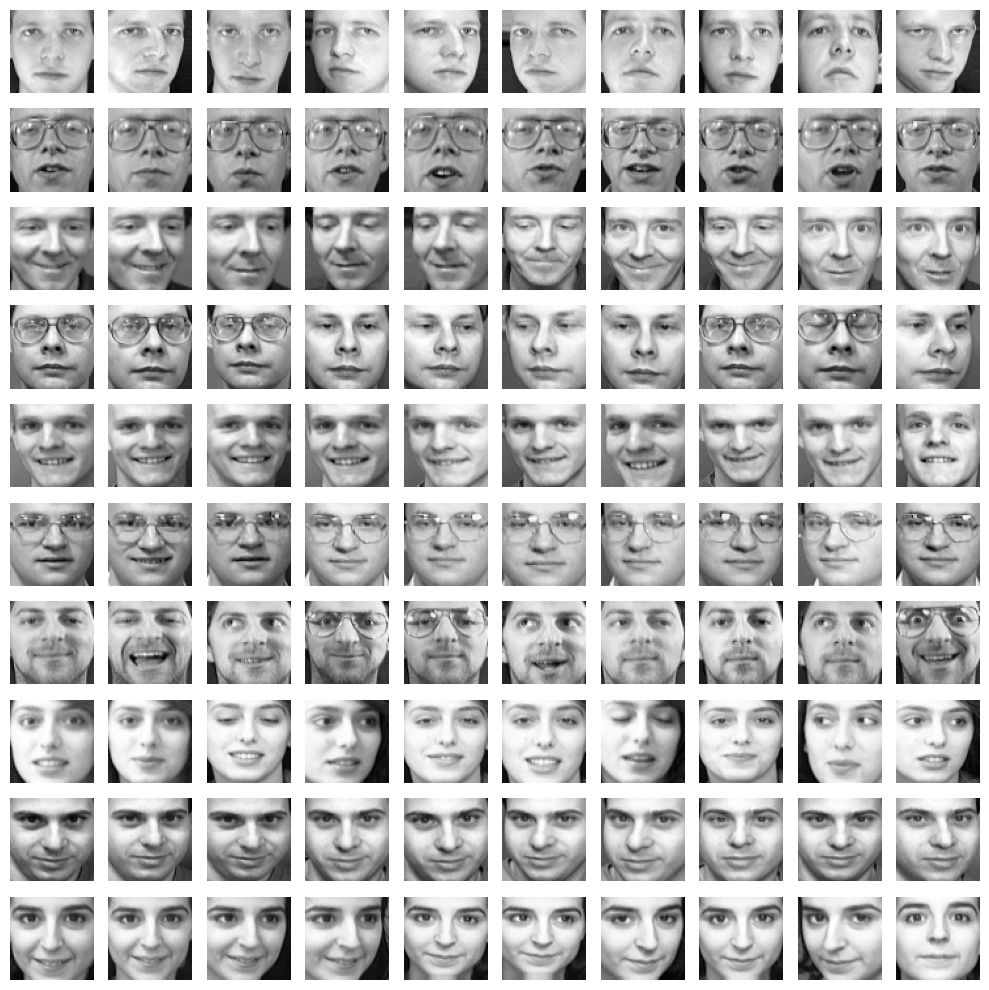

In [6]:
n, m = 64, 64 # image size
show_montage(X, n, m, 10, 10) # 顯示前 100 張影像


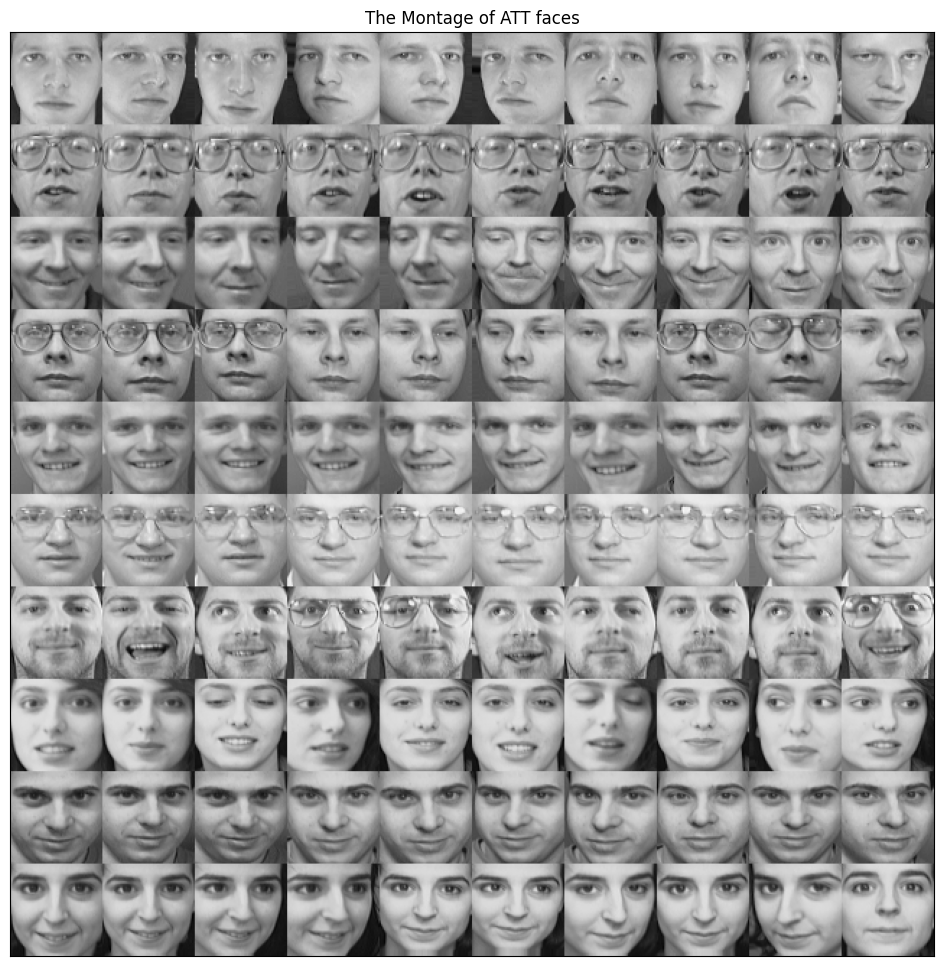

In [14]:
plt.figure(figsize = (12, 12))
m, n = 10, 10  # A m x n montage (total mn images)
# Arrange images to form a montage  
M = montage_pkg(X, m, n)
plt.imshow(M, cmap = 'gray') # gray_r: reverse gray colormap
plt.xticks([])
plt.yticks([])
plt.title('The Montage of ATT faces')
plt.show()